#### **Exploratory Data Analysis, KPI Calculation & Data Quality Profiling**

**Business Context**: This analysis supports Mastercard Foundation’s Young Africa Works strategy — enabling young Africans (especially young women) to access dignified and fulfilling work through education-to-employment programs.

#### Imports and setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load raw data
participants = pd.read_csv('../data/raw/participants.csv')
enrollments = pd.read_csv('../data/raw/enrollments.csv')
placements = pd.read_csv('../data/raw/placements.csv')
follow_ups = pd.read_csv('../data/raw/post_placement_followups.csv')

# Date conversion
date_cols = ['registration_date', 'enrollment_date', 'placement_date', 'followup_6m_date']
for df in [participants, enrollments, placements, follow_ups]:
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')

print("Datasets loaded successfully")
print(f"Participants : {len(participants):,}")
print(f"Enrollments  : {len(enrollments):,}")
print(f"Placements   : {len(placements):,}")

Datasets loaded successfully
Participants : 25,000
Enrollments  : 25,000
Placements   : 19,324


#### High-Level Overview

In [2]:
print("=== Time Period ===")
print(f"From: {enrollments['enrollment_date'].min().date()}")
print(f"To   : {enrollments['enrollment_date'].max().date()}\n")

print("=== Gender Distribution (Target ~70% Female) ===")
print(enrollments['gender'].value_counts(normalize=True).round(3)*100)

print("\n=== Country Distribution ===")
print(enrollments['country'].value_counts())

=== Time Period ===
From: 2022-01-01
To   : 2025-03-31

=== Gender Distribution (Target ~70% Female) ===
gender
Female    68.3
Male      31.7
Name: proportion, dtype: float64

=== Country Distribution ===
country
Kenya       6210
Nigeria     5780
Ethiopia    5503
Ghana       3790
Rwanda      3717
Name: count, dtype: int64


#### Enterprise KPI Dashboard Calculations



In [3]:
base = enrollments.merge(placements, on='participant_id', how='left', suffixes=('', '_placement'))
base = base.merge(follow_ups[['participant_id', 'still_employed_6m', 'followup_6m_date']], 
                  on='participant_id', how='left')

# Core KPIs
kpis = {
    "Total_Participants": len(base),
    "Overall_Placement_Rate": base['placed'].mean(),
    "Female_Placement_Rate": base[base['gender'] == 'Female']['placed'].mean(),
    "Male_Placement_Rate": base[base['gender'] == 'Male']['placed'].mean(),
    "6M_Retention_Rate": base['still_employed_6m'].mean(),
    "Avg_Monthly_Income_USD": base['monthly_income_usd'].mean(),
    "Gender_Parity_Index": base[base['gender'] == 'Female']['placed'].mean() / 
                          base[base['gender'] == 'Male']['placed'].mean()
}

print("=== MASTER CARD FOUNDATION ALIGNED KPIs ===")
for k, v in kpis.items():
    if "Rate" in k or "Index" in k:
        print(f"{k:35} : {v:.1%}")
    elif "Income" in k:
        print(f"{k:35} : ${v:,.0f}")
    else:
        print(f"{k:35} : {v:,.0f}")

=== MASTER CARD FOUNDATION ALIGNED KPIs ===
Total_Participants                  : 25,000
Overall_Placement_Rate              : 77.9%
Female_Placement_Rate               : 78.1%
Male_Placement_Rate                 : 77.4%
6M_Retention_Rate                   : 69.4%
Avg_Monthly_Income_USD              : $283
Gender_Parity_Index                 : 100.9%


#### Data Quality Profiling

In [4]:
def profile_dq(df, name):
    print(f"\n--- Data Quality: {name} ---")
    print(f"Rows: {len(df):,}")
    missing = df.isnull().sum()
    print("Missing Values (%):")
    print((missing[missing > 0] / len(df) * 100).round(2))
    print(f"Duplicate participant_id: {df['participant_id'].duplicated().sum()}")

profile_dq(participants, "Participants")
profile_dq(placements, "Placements")
profile_dq(follow_ups, "Post-Placement Follow-ups")


--- Data Quality: Participants ---
Rows: 25,000
Missing Values (%):
Series([], dtype: float64)
Duplicate participant_id: 0

--- Data Quality: Placements ---
Rows: 19,324
Missing Values (%):
employment_type       22.12
monthly_income_usd    22.12
dtype: float64
Duplicate participant_id: 0

--- Data Quality: Post-Placement Follow-ups ---
Rows: 15,049
Missing Values (%):
monthly_income_usd    3.0
dtype: float64
Duplicate participant_id: 0


#### Visual Insights

C:\Users\tohiba\AppData\Local\Temp\ipykernel_7460\703958518.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=placement_by_country.index, y=placement_by_country.values, palette='viridis')


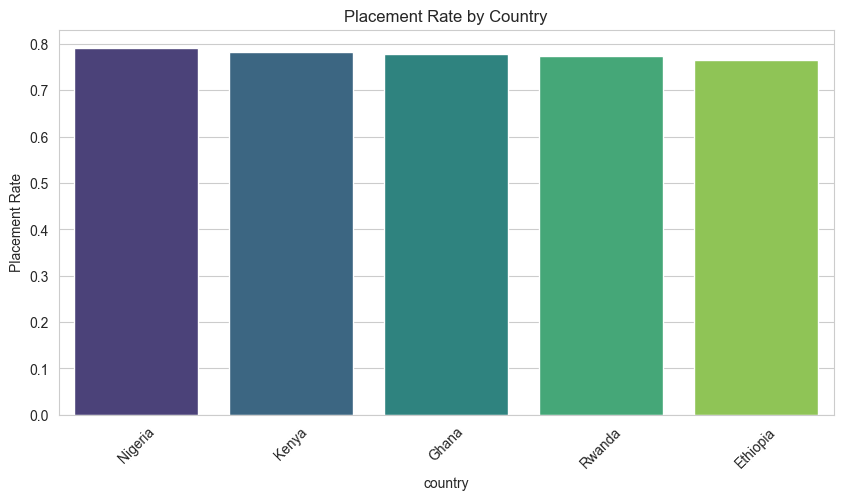

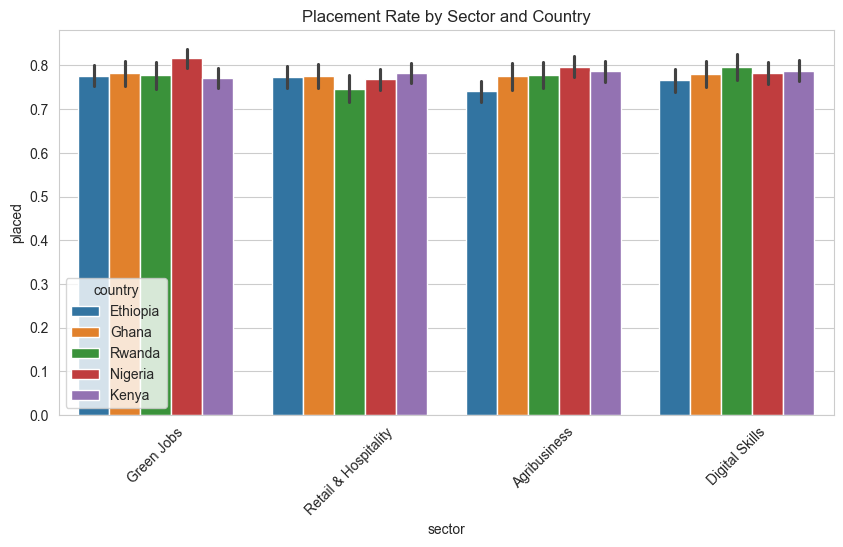

In [5]:
# 1. Placement Rate by Country
plt.figure(figsize=(10, 5))
placement_by_country = base.groupby('country')['placed'].mean().sort_values(ascending=False)
sns.barplot(x=placement_by_country.index, y=placement_by_country.values, palette='viridis')
plt.title('Placement Rate by Country')
plt.ylabel('Placement Rate')
plt.xticks(rotation=45)
plt.show()

# 2. Sector Performance
plt.figure(figsize=(10, 5))
sns.barplot(data=base, x='sector', y='placed', hue='country', estimator=np.mean)
plt.title('Placement Rate by Sector and Country')
plt.xticks(rotation=45)
plt.show()

#### Save Processed Files

In [6]:
base.to_csv('../data/processed/merged_analytical_base.csv', index=False)

kpi_summary = pd.DataFrame.from_dict(kpis, orient='index', columns=['Value'])
kpi_summary.to_csv('../data/processed/kpi_summary.csv')

print("\nEDA & Profiling Completed. Files saved to ../data/processed/")


EDA & Profiling Completed. Files saved to ../data/processed/
